In [1]:
import pandas as pd

In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 22.7 MB/s eta 0:00:001m22.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 47.1 MB/s eta 0:00:00 MB/s eta 0:00:01


Parte 1 – Análisis básico del dataset (10 puntos)

1. Carga y exploración inicial
Cargue el dataset y muestre sus primeras filas. Indique el número de filas y columnas.


Resp: aqui esta el codigo para mostrar las filas y columnas

In [2]:
area = pd.read_csv("area_protegida.csv")

In [9]:
print("Primeras 10 filas:")
print(area.head(10))

Primeras 10 filas:
         lat        lng  gid entidad          objeto  \
0 -53.546655 -68.041297  362   falso  Área protegida   
1 -31.404445 -64.357709  157   falso  Área protegida   
2 -32.245004 -60.734423  169   falso  Área protegida   
3 -26.031780 -54.418743   47   falso  Área protegida   
4 -26.402258 -65.680992  206   falso  Área protegida   
5 -27.630853 -67.275597  213   falso  Área protegida   
6 -33.804530 -59.291954   99   falso  Área protegida   
7 -47.925458 -72.317514  223   falso  Área protegida   
8 -50.337227 -69.017112  230   falso  Área protegida   
9 -27.474382 -55.001868   65   falso  Área protegida   

                                                 fna  \
0  Sitio RAMSAR y Reserva Hemisférica Costa Atlán...   
1            Reserva Natural de la Defensa La Calera   
2                      Sitio Ramsar Delta del Parana   
3   Parque Natural Municipal Lote C Huerto Municipal   
4              Parque Provincial Cumbres Calchaquíes   
5            Area Natural Pr

utilizamos shape para saber el numero de filas y columnas:

In [11]:

print(area.shape)


(395, 14)


2. Estructura y tipos de datos
Identifique el tipo de dato de cada columna (numérico, categórico, fecha, geográfico, etc.) y presente un resumen de los tipos.


esto se puede entender con mejor facilidad utilizando Dtypes

In [12]:
print("Primeras 10 filas:")
print(area.dtypes)

Primeras 10 filas:
lat        float64
lng        float64
gid          int64
entidad        str
objeto         str
fna            str
gna            str
nam            str
tap          int64
jap          int64
caa          int64
fdc            str
sag            str
area         int64
dtype: object


resumiendo los tipos:

lat ing: corresponden a un tipo de dato geografico

gid: es un identificador de grupo numerico

entidad: reconoce un lugar como parte del dataset

objeto: identifica una zona como parte de las areas protegidas

fna: es la firma de nombre geografico (nombre completo)

gna: significa genero del nombre geografico (termino generico)

nam: nombre geografico generico (termino especifico)

tap: tipo de area

jap: jurisdiccion

caa: Clasificación de acuerdo al tipo de autoridad responsable

fdp: fuente de captura

sad: Nombre de la autoridad responsable de la información utilizada


In [ ]:
area: identificador de area por cordenada

3. Estadísticas descriptivas
Calcule y comente las principales medidas de resumen (media, mediana, mínimo, máximo, desviación estándar) para las variables numéricas.


resp: calculo y resumen numerico de longitud (lng)


con max se calcula el valor maximo

In [13]:
print(area["lng"].max())

-53.7909397257891


con min se calcula el valor minimo

In [14]:
print(area["lng"].min())

-73.402908018618


con mean se calcula el promedio

In [15]:
print(area["lng"].mean())

-63.44387137479367


con std se puede calcula la desviacion estandar

In [16]:
area["lng"].std()

np.float64(5.700540091735373)

4. Valores nulos
Detecte la cantidad de valores faltantes por columna y proponga una estrategia para tratarlos (eliminación, imputación, etc.). Justifique su decisión.


resp. asi se obtienen los valores nulos

In [11]:

print(area.isnull().sum())

lat         0
lng         0
gid         0
entidad     0
objeto      0
fna         0
gna         0
nam         0
tap         0
jap         0
caa         0
fdc        59
sag         1
area        0
dtype: int64


5. Frecuencias de variables categóricas
Para al menos tres variables categóricas, calcule sus frecuencias. Identifique la categoría más frecuente.

resp. esta es la manera de calcular la frecuencia de una variable

In [14]:
filtr1 = area["tap"].value_counts()
print(filtr1)

tap
2    284
1     95
3     12
0      4
Name: count, dtype: int64


aqui el tipo de tap [tipo de area] mas frecuente es tipo 2 [reserva]

In [ ]:
frecuencia de jap:

In [15]:
filtr1 = area["jap"].value_counts()
print(filtr1)

jap
 3    222
 2    103
 5     33
 4     32
 0      3
-1      2
Name: count, dtype: int64


aqui el tipo jap [jurisdiccion] mas frecuente es 3 [provincial]

In [16]:
filtr1 = area["caa"].value_counts()
print(filtr1)

caa
 17    353
 3      34
 0       4
-1       4
Name: count, dtype: int64


aqui el tipo de caa [autoridad responsable] es 17

6. Filtros básicos
Realice al menos dos filtros diferentes para obtener subconjuntos de datos según condiciones lógicas (por ejemplo, registros de una región específica, valores superiores a un umbral, etc.). Muestre los tamaños de los subconjuntos.

Parte 2 – Preguntas de análisis (10 preguntas)

In [10]:
import plotly.express as px

In [11]:
import folium

In [13]:
!pip install plotly

---Filtrar: condición de una columna, por más de una columna.

       preguntas:

1.filtro:¿Cuál es el área promedio de los Parques Nacionales (tap == 1 y jap == 2)? ¿Y de las Reservas Provinciales (tap == 2 y jap == 3)?

      Resp:

In [3]:
filtr = area[(area["tap"] == 1)&(area.jap == 2)]
filtr.area.mean()

np.float64(913448.268292683)

explicacion: aqui se utiliza "&" para adjuntar dos  instancias y filtrarlas como una sola variable

---Gráficos: torta, barra(datos ordenados), línea

    preguntas:

1.Gráfico: crear un grafico potly bar que identifique el nombre de las areas del subtipo jurisdiccion privada (jap valor de 5) ¿cual es el area de jurisdiccion privada mas frecuente?

     Resp:

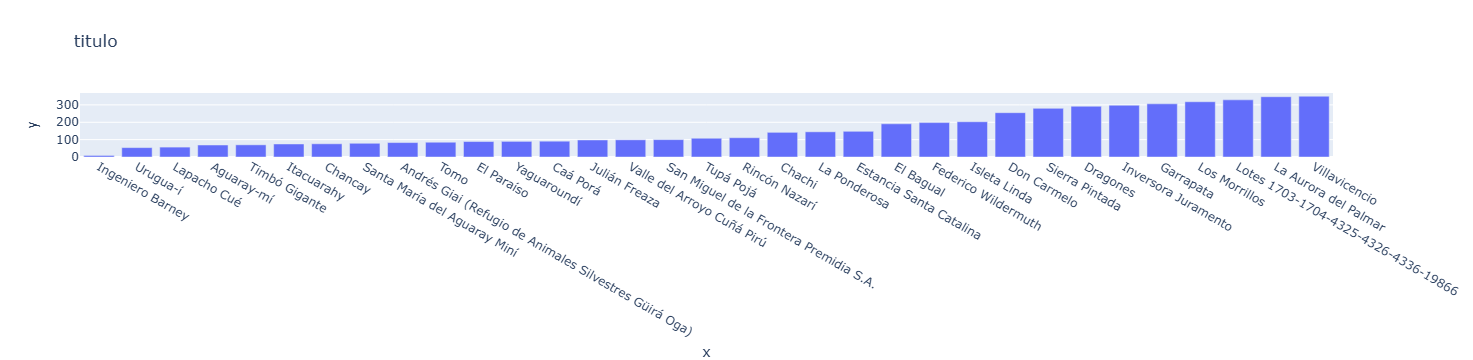

In [18]:
filtr2 = area[area["jap"] == 5]
filtr3 = filtr2["nam"]
fig = px.bar(
    x = filtr3.values, y = filtr3.index, title = "titulo")
fig.show()

explicacion: aqui se utilizo la herramienta potly bar, intanciandole un valor, para mostrar por nombre cual area tipo jurisdiccion privada es mas frecuente.

2.grafico: ¿Cuál es el tipo de área protegida (tap) mayor a la longitud (lng) promedio mas frecuente?

          Resp:

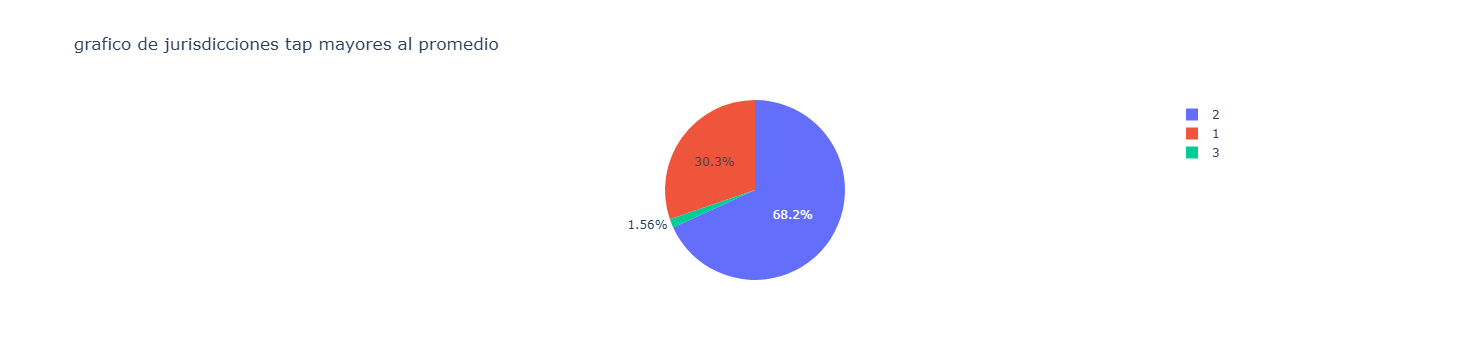

In [26]:
filtr2 = area[area["lng"] > -63]
filtr3 = filtr2["tap"]
pig = px.pie(
    data_frame = filtr3, values = filtr3.index, names = filtr3.values, title = "grafico de jurisdicciones tap mayores al promedio")
pig.show()

In [ ]:
explicacion: aqui se utilizo la herramienta poylt pie, se filtro por dos variables distintas; una que guardaba el promedio de longitud lng, y otra que lo filtraba por tipo tap.

3.grafico utilizando potly line, queremos generar un grafico que muestre las areas protegidas; parques nacionales ("tap 1" y "jap 2")

      Resp:

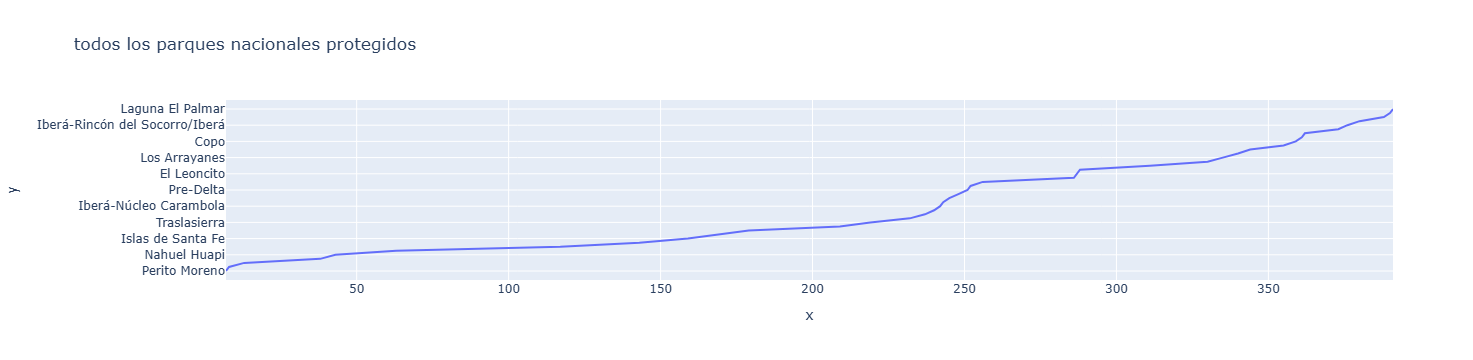

In [66]:
filtr1 = area[(area["tap"] == 1)&(area.jap == 2)]
filtr2 = filtr1["nam"]
dig = px.line(
    filtr2, y = filtr2.values, x = filtr2.index, title = "todos los parques nacionales protegidos")
dig.show()


Explicacion: utilizando la funcion "&" para adjuntar dos instancias como una sola variable (parques naciones = tap 1 y jap 2) y filtrando luego por nombre, con potly line creamos nuestro grafico.